<a href="https://colab.research.google.com/github/Frestka/Mining_Premier_League/blob/main/notebooks/Feature_extraction_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Frestka/Mining_Premier_League/blob/main/notebooks/Feature_extraction_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup e Caricamento

In [1]:
# Rilevamento automatico ambiente: esegui questa cella liberamente su Colab E in locale
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os, sys
    from pathlib import Path

    REPO_NAME = "Mining_Premier_League"
    REPO_URL  = "https://github.com/Frestka/Mining_Premier_League.git"

    os.chdir("/content")
    if not os.path.exists(REPO_NAME):
        !git clone -q {REPO_URL}
    os.chdir(REPO_NAME)
    sys.path.insert(0, os.path.abspath("."))

    !git fetch -q origin
    !git checkout -q origin/main
    !pip install -q -r requirements.txt
    Path("data/processed").mkdir(parents=True, exist_ok=True)

    import gdown
    FILES = {
        "data/processed/dataset_clean.parquet": "1gCE4B6r1wngsEorSU-7WMsGKWbHwUYwd",  # Silver layer
    }

    for path, file_id in FILES.items():
        if not os.path.exists(path):
            print(f"Download {path}...")
            gdown.download(id=file_id, output=path, quiet=False, fuzzy=True)
        else:
            print(f"Gia presente, skip -> {path}")

    print(f"\nSetup Colab completato. Cartella: {os.getcwd()}")

else:
    print("Ambiente locale rilevato: setup Colab saltato automaticamente.")

error: pathspec 'src/' did not match any file(s) known to git
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 2.4 MB/s eta 0:00:00
Download data/processed/dataset_clean.parquet...


Downloading...
From: https://drive.google.com/uc?id=1gCE4B6r1wngsEorSU-7WMsGKWbHwUYwd
To: /content/Mining_Premier_League/data/processed/dataset_clean.parquet
100%|██████████| 16.0M/16.0M [00:00<00:00, 50.0MB/s]


Setup Colab completato. Cartella: /content/Mining_Premier_League


In [2]:
import sys, os
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

def setup_project():
    root = Path.cwd()
    while not (root / 'requirements.txt').exists() and root.parent != root:
        root = root.parent
    if not (root / 'requirements.txt').exists():
        raise RuntimeError(
            "File requirements.txt non trovato. Su Colab esegui prima la cella Setup Colab. "
            "In locale apri il notebook dalla root del repo o da notebooks/."
        )
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    os.chdir(root)
    return root

PROJECT_ROOT = setup_project()
print(f'Project root: {PROJECT_ROOT}')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='tab10')

df = pd.read_parquet('data/processed/dataset_clean.parquet')
print(f'Dataset Silver caricato con successo!')
print(f'Dimensioni: {df.shape[0]:,} righe x {df.shape[1]} colonne')

Project root: /content/Mining_Premier_League
Dataset Silver caricato con successo!
Dimensioni: 606,135 righe x 62 colonne


## Derivazione del Target (Win, Draw, Loss)

Avendo già a disposizione il `match_id` e un dataset pulito (dal Notebook 1), procediamo al calcolo dei goal segnati e subiti da ciascuna squadra.


In [3]:
# Il dataset è già pulito e contiene solo eventi di gioco e il match_id.\n
df_game = df.copy()
n_matches = df_game["match_id"].nunique()
print(f"Partite identificate: {n_matches}  (attese: 380 per PL 2020-21)\n")

# Goal per squadra per match
goals_df = (
    df_game[df_game["type_displayName"] == "Goal"]
    .groupby(["match_id", "teamId"])
    .size()
    .reset_index(name="goals_scored")
)

# Matrice completa match x team (include squadre con 0 goal)
all_pairs = (
    df_game.groupby(["match_id", "teamId"])
    .size()
    .reset_index(name="total_events")[["match_id", "teamId"]]
)

results_df = all_pairs.merge(goals_df, on=["match_id", "teamId"], how="left")
results_df["goals_scored"] = results_df["goals_scored"].fillna(0).astype(int)

# Goal subiti = totale gol del match - gol segnati (vettorializzato)
total_goals = results_df.groupby("match_id")["goals_scored"].transform("sum")
results_df["goals_conceded"] = total_goals - results_df["goals_scored"]
opp = results_df.copy()

def outcome(row):
    if   row["goals_scored"] > row["goals_conceded"]: return "Win"
    elif row["goals_scored"] < row["goals_conceded"]: return "Loss"
    else:                                              return "Draw"

opp["outcome"] = opp.apply(outcome, axis=1)

print("\nDistribuzione outcome (per team-match):")
print(opp["outcome"].value_counts())

avg_goals = opp.groupby("match_id")["goals_scored"].sum().mean()
print(f"\nMedia goal per partita: {avg_goals:.2f}  (PL 2020-21 reale: ~2.7)")

n_partite_uniche = opp['match_id'].nunique()
print(f"\nPartite uniche nel dataset: {n_partite_uniche}")

expected_rows = n_partite_uniche * 2
print(f"Righe attese (2 per partita): {expected_rows}")
print(f"Righe attuali nel dataset: {len(opp)}")

duplicati = opp.duplicated(subset=['match_id', 'teamId']).sum()
print(f"Righe duplicate (stessa partita e stessa squadra): {duplicati}")

if len(opp) != expected_rows:
    print("\nATTENZIONE: Il numero di righe non corrisponde al doppio delle partite!")
else:
    print("\nTUTTO OK: Hai esattamente due righe per ogni partita.")

Partite identificate: 380  (attese: 380 per PL 2020-21)


Distribuzione outcome (per team-match):
outcome
Win     300
Loss    300
Draw    160
Name: count, dtype: int64

Media goal per partita: 2.69  (PL 2020-21 reale: ~2.7)

Partite uniche nel dataset: 380
Righe attese (2 per partita): 760
Righe attuali nel dataset: 760
Righe duplicate (stessa partita e stessa squadra): 0

TUTTO OK: Hai esattamente due righe per ogni partita.


## Feature Extraction — Aggregazione evento → squadra-partita

Questo è il passaggio centrale del notebook. Aggreghiamo il dataset da **606k righe** (1 riga = 1 evento) a **760 righe** (1 riga = 1 squadra in 1 partita) tramite `groupby(['match_id', 'teamId']).apply(extract_features)`.


> **Data Leakage:** `n_goals` e `shot_conversion_rate` vengono estratte qui per completezza dell'EDA (sono utili per mostrare *quali* feature sono discriminanti), ma verranno **escluse da `FEATURE_COLS_ML` in NB3** prima di qualsiasi addestramento. Entrambe sono derivazioni dirette dei gol segnati, che per definizione determinano il risultato della partita.

In [4]:
# --- CELLA 6 (Definizione Funzione) ---
# Creiamo il flag di successo prima del groupby per efficienza
if "outcomeType_displayName" in df_game.columns:
    df_game["is_successful"] = df_game["outcomeType_displayName"] == "Successful"

def extract_features(grp):
    """
    Estrae le feature tattiche e spaziali per squadra-partita.
    Previene il Data Leakage ignorando i gol.
    """
    total_events = len(grp)
    minutes_played = grp["minute"].clip(upper=120).max() - grp["minute"].clip(upper=120).min()
    minutes_played = max(minutes_played, 1)

    # Sub-dataframe
    passes = grp[grp["type_displayName"] == "Pass"]
    # FIX LEAKAGE: Un tiro è valido se isShot è True MA isGoal è False
    shots = grp[(grp.get("isShot", False) == True) & (grp.get("isGoal", False) == False)]
    goals = grp[grp["type_displayName"] == "Goal"]
    tackles = grp[grp["type_displayName"] == "Tackle"]
    fouls = grp[grp["type_displayName"] == "Foul"]
    corners = grp[grp["type_displayName"] == "CornerAwarded"]
    aerials = grp[grp["type_displayName"] == "Aerial"]
    clearances = grp[grp["type_displayName"] == "Clearance"]
    intercepts = grp[grp["type_displayName"] == "Interception"]
    takeons = grp[grp["type_displayName"] == "TakeOn"]
    recoveries = grp[grp["type_displayName"] == "BallRecovery"]

    ft = grp[grp["period_displayName"] == "FirstHalf"]

    def safe_rate(num, den):
        return num / den if den > 0 else 0.0

    # Coordinate Spaziali Sicure
    avg_x = grp["x"].mean()
    avg_y = grp["y"].mean()
    avg_pass_end_x = passes["endX"].mean() if "endX" in passes.columns else np.nan

    # Field Tilt
    offensive_third = grp[grp['x'] > 66.6]
    field_tilt = len(offensive_third) / total_events if total_events > 0 else 0.0

    # Gestione Cartellini
    n_yellow = grp[grp['cardType_displayName'] == 'Yellow'].shape[0]
    red_events = grp[grp['cardType_displayName'].isin(['Red', 'SecondYellow'])]
    n_red = red_events['playerId'].nunique() if 'playerId' in red_events.columns else red_events.shape[0]

    # --- FUNZIONI HELPER PER ESTRAZIONI SICURE ---
    def safe_sum(col_name):
        return grp[col_name].sum() if col_name in grp.columns else 0

    def safe_mean(col_name):
        return grp[col_name].mean() if col_name in grp.columns else np.nan


    return pd.Series({
        # 1. Metriche Volume Base
        "n_passes": len(passes),
        "n_shots_no_goal": len(shots),
        "n_tackles": len(tackles),
        "n_fouls": len(fouls),
        "n_corners": len(corners),
        "n_aerials": len(aerials),
        "n_clearances": len(clearances),
        "n_interceptions": len(intercepts),
        "n_takeons": len(takeons),
        "n_ball_recoveries": len(recoveries),
        "events_per_minute": total_events / minutes_played,
        "first_half_ratio":  safe_rate(len(ft), total_events),

        # 2. Metriche Tattiche Avanzate (dai Qualifiers)
        "n_longballs": safe_sum('is_longball'),
        "n_crosses": safe_sum('is_cross'),
        "n_throughballs": safe_sum('is_throughball'),
        "n_accurate_keypasses": (passes["is_keypass"] & passes["is_successful"]).sum() if ("is_keypass" in passes.columns and "is_successful" in passes.columns) else 0,
        "n_fastbreaks": safe_sum('is_fastbreak'),

        # Somme sicure aggregate
        "n_big_chances": safe_sum('is_bigchance') + safe_sum('is_bigchancecreated'),
        "n_blocks": safe_sum('is_blocked') + safe_sum('is_outfielderblock') + safe_sum('is_sixyardblock'),

        # 3. Metriche Spaziali e Dominio Territoriale
        "avg_x": avg_x,
        "avg_y": avg_y,
        "avg_pass_end_x": avg_pass_end_x,
        "field_tilt": field_tilt,
        "n_passes_offensive_third": len(offensive_third[offensive_third['type_displayName'] == 'Pass']),
        "avg_pass_length": safe_mean('pass_length'),
        "avg_goal_mouth_z": safe_mean('goalMouthZ'),
        "set_piece_ratio": safe_rate((safe_sum('is_fromcorner') + safe_sum('is_setpiece')), len(shots)),

        # 4. Disciplina
        "n_yellow_cards": n_yellow,
        "n_red_cards": n_red,

        # 5. Ratei di Efficienza
        "pass_success_rate": safe_rate(passes["is_successful"].sum(), len(passes)) if "is_successful" in passes.columns else np.nan,
        "tackle_success_rate": safe_rate(tackles["is_successful"].sum(), len(tackles)) if "is_successful" in tackles.columns else np.nan,
        "aerial_success_rate": safe_rate(aerials["is_successful"].sum(), len(aerials)) if "is_successful" in aerials.columns else np.nan,
        "takeon_success_rate": safe_rate(takeons["is_successful"].sum(), len(takeons)) if "is_successful" in takeons.columns else np.nan,
    })

print("Funzione 'extract_features' definita con successo. Pronta per il groupby!")



Funzione 'extract_features' definita con successo. Pronta per il groupby!


## Feature Engineering Relazionale


### 1. Co-occorrenza degli eventi (Livello Micro → Macro)
Un'azione tecnica vale solo se completata. Abbiamo ingegnerizzato la feature **`n_accurate_keypasses`** combinando `is_keypass` con `outcomeType == 'Successful'`, fondendo le variabili binarie a livello di singolo evento prima dell'aggregazione a livello di partita. Per eliminare la **multicollinearità**, abbiamo rimosso la variabile originale `n_keypasses` (il "parent"), costringendo il modello a valutare solo la qualità pura del gesto tecnico.

### 2. Sfruttamento della struttura di gruppi (Livello Macro — Confronto con il Rivale)
Ogni `match_id` raggruppa esattamente 2 righe (le 2 squadre sfidanti). Abbiamo sfruttato questa struttura per costruire **feature relazionali di dominanza**: `pass_dominance` e `big_chance_dominance`. Un valore vicino a 1.0 indica dominanza assoluta; 0.5 indica parità.


In [5]:
# --- CELLA 7 (Esecuzione Unica) ---
import time

print("Avvio aggregazione feature tattiche. Attendere...")
start_time = time.time()

# Esecuzione dell'aggregazione (con i FIX per Pandas)
features_raw = (
    df_game.groupby(["match_id", "teamId"], group_keys=False)
    .apply(extract_features, include_groups=False)
    .reset_index()
)

# Uniamo il dataset con il target (esito e goal)
features = features_raw.merge(
    opp[["match_id", "teamId", "goals_scored", "goals_conceded", "outcome"]],
    on=["match_id", "teamId"],
    how="inner"
)

# Sicurezza finale per il ML: sostituiamo eventuali NaN con 0
features = features.fillna(0)

# ── Feature Relazionali di Dominanza
# Queste feature confrontano le 2 squadre dello stesso match (struttura a gruppi).
# match_id raggruppa esattamente 2 righe (le 2 squadre della partita).
# Valori vicini a 1.0 = dominanza assoluta; 0.5 = parità.

features['pass_dominance'] = features.groupby('match_id')['n_passes'].transform(
    lambda x: x / x.sum() if x.sum() > 0 else 0.5
)
features['big_chance_dominance'] = features.groupby('match_id')['n_big_chances'].transform(
    lambda x: x / x.sum() if x.sum() > 0 else 0.5
)

print(" Feature relazionali aggiunte: pass_dominance, big_chance_dominance")
print(f"   Verifica: {features[['match_id','pass_dominance','big_chance_dominance']].head(4).to_string()}")

end_time = time.time()
print(f"Aggregazione completata in {end_time - start_time:.2f} secondi.")
print(f"Dimensioni dataset Gold: {features.shape[0]} righe × {features.shape[1]} colonne (Attesi: 760 righe)")

# Definiamo rigorosamente le feature
FEATURE_COLS = [c for c in features.columns
                if c not in ["match_id", "teamId", "goals_scored",
                             "goals_conceded", "outcome"]]

print(f"\nColonne feature pronte per l'EDA e il ML: {len(FEATURE_COLS)}")
print("\nAnteprima delle nuove metriche estratte:")
print(features[['teamId', 'n_passes', 'n_longballs', 'n_big_chances', 'n_fastbreaks', 'pass_success_rate', 'outcome']].head())

# --- CELLA 9 (EDA 1-Sigma Pulita) ---
OUTCOME_ORDER = ["Win", "Draw", "Loss"]
PALETTE = {"Win": "#10B981", "Draw": "#F59E0B", "Loss": "#EF4444"}

# ESCLUSIONE DATA LEAKAGE: Rimuoviamo n_goals e conversion rate prima del test
eda_cols = [c for c in FEATURE_COLS if c not in ['n_goals', 'shot_conversion_rate']]

class_means = features.groupby("outcome")[eda_cols].mean()
global_std  = features[eda_cols].std()

print("--- Media per classe (Win / Draw / Loss) ---")
# Stampiamo solo alcune colonne per brevità
print(class_means[['n_passes', 'n_big_chances', 'n_accurate_keypasses', 'avg_x']].round(2).T.to_string())

# Manteniamo per retrocompatibilità cella 13
diff_win_loss = (class_means.loc["Win"] - class_means.loc["Loss"]).abs()

print("\n--- Analisi significatività (> 1sigma) TATTICA ---")
pairs = [("Win", "Loss"), ("Win", "Draw"), ("Draw", "Loss")]
for c1, c2 in pairs:
    diff = (class_means.loc[c1] - class_means.loc[c2]).abs()
    significant = diff[diff > global_std]
    print(f"\n--- {c1} vs {c2} ---")
    print(f"Feature significative (> 1σ): {len(significant)}")
    for feat in diff.sort_values(ascending=False).head(10).index:
        sd = global_std[feat]
        marker = "[SÌ]" if feat in significant.index else "[NO]"
        print(f"{marker} {feat:<26} {c1}={class_means.loc[c1, feat]:.2f}  "
              f"{c2}={class_means.loc[c2, feat]:.2f}  "
              f"|diff|={diff[feat]:.2f}  sigma={sd:.2f}  -> {diff[feat]/sd:.1f}sigma")


Avvio aggregazione feature tattiche. Attendere...
 Feature relazionali aggiunte: pass_dominance, big_chance_dominance
   Verifica:    match_id  pass_dominance  big_chance_dominance
0         1        0.618367                   0.4
1         1        0.381633                   0.6
2         2        0.313646                   0.0
3         2        0.686354                   1.0
Aggregazione completata in 20.61 secondi.
Dimensioni dataset Gold: 760 righe × 40 colonne (Attesi: 760 righe)

Colonne feature pronte per l'EDA e il ML: 35

Anteprima delle nuove metriche estratte:
   teamId  n_passes  n_longballs  n_big_chances  n_fastbreaks  \
0      32     606.0         61.0            2.0           1.0   
1     184     374.0         94.0            3.0           0.0   
2      24     308.0         68.0            0.0           2.0   
3     167     674.0         53.0            4.0           1.0   
4      18     638.0         88.0            4.0           0.0   

   pass_success_rate outcome  

### Recap: Il Dataset Finale — Feature Nuove Ingegnerizzate ed Estratte

Il risultato della nostra aggregazione è un dataset di **760 righe e 40 colonne** (`features.parquet`).

La maggior parte delle **35 feature tattiche** (conteggi di passaggi, tackle, falli, coordinate spaziali, ratei di efficienza) sono state già descritte nel Notebook 1 ([Data_Cleaning_and_Understanding.ipynb](Data_Cleaning_and_Understanding.ipynb)) durante l'interpretazione delle colonne grezze.

In questo notebook abbiamo aggiunto **nuove feature ingegnerizzate** attraverso due strategie distinte:

#### **1. Feature Estratte dalla Colonna `qualifiers` (6 feature)**
Durante il parsing del JSON `qualifiers` nel Notebook 1, abbiamo estratto le seguenti metriche tattiche avanzate:
- `n_longballs`: Passaggi lunghi tentati
- `n_crosses`: Cross effettuati verso l'area
- `n_throughballs`: Passaggi filtranti (tagliano le linee difensive)
- `n_fastbreaks`: Azioni veloci di contropiede
- `n_big_chances`: Grandi occasioni prodotte
- `n_blocks`: Tiri avversari bloccati fisicamente

#### **2. Feature Ingegnerizzate — Variabile Fusa (1 feature)**
- `n_accurate_keypasses`: *(Variabile Fusa per ridurre multicollinearità)* Passaggi chiave che hanno avuto successo. Ottiene combinando `is_keypass` AND `is_successful` a livello di singolo evento (prima dell'aggregazione), quindi il "parent" `n_keypasses` è stato rimosso per evitare ridondanza e multicollinearità nel modello.

#### **3. Feature Relazionali — Dominanza (2 feature)**
Sfruttano la struttura a gruppi del dataset: ogni `match_id` raggruppa esattamente 2 squadre (i 2 contendenti della stessa partita).
- `pass_dominance`: Rapporto fra i passaggi della squadra e il totale dei passaggi nel match (1.0 = dominio totale; 0.5 = parità)
- `big_chance_dominance`: Rapporto fra le grandi occasioni della squadra e il totale nel match

**Sommario**:
- `35 feature tattiche totali`: 6 da qualifiers + 1 fusa + 2 relazionali + 26 base (già descritte nel NB1)
- `5 feature Identificativi/Target`: match_id, teamId, goals_scored, goals_conceded, outcome

## Exploratory Data Analysis (EDA)

### Medie per classe e analisi della significatività

Come richiesto dalla traccia, confrontiamo le medie di ogni feature tra le classi Win, Draw e Loss. Una feature è considerata **discriminante** se la differenza assoluta tra il valore medio della classe Win e quello della classe Loss supera **1 deviazione standard globale** (calcolata sull'intero dataset, non per classe).

In [6]:
OUTCOME_ORDER = ["Win", "Draw", "Loss"]
PALETTE = {"Win": "#10B981", "Draw": "#F59E0B", "Loss": "#EF4444"}

class_means = features.groupby("outcome")[FEATURE_COLS].mean()
global_std  = features[FEATURE_COLS].std()

print("--- Media per classe (Win / Draw / Loss) ---")
print(class_means.round(3).T.to_string())

# Manteniamo per cella 13
diff_win_loss = (class_means.loc["Win"] - class_means.loc["Loss"]).abs()

print("\n--- Analisi significatività (> 1sigma) ---")
pairs = [("Win", "Loss"), ("Win", "Draw"), ("Draw", "Loss")]
for c1, c2 in pairs:
    diff = (class_means.loc[c1] - class_means.loc[c2]).abs()
    significant = diff[diff > global_std]
    print(f"\n--- {c1} vs {c2} ---")
    print(f"Feature significative (> 1σ): {len(significant)}")
    for feat in diff.sort_values(ascending=False).head(10).index:
        sd = global_std[feat]
        marker = "[SÌ]" if feat in significant.index else "[NO]"
        print(f"{marker} {feat:<26} {c1}={class_means.loc[c1, feat]:.2f}  "
              f"{c2}={class_means.loc[c2, feat]:.2f}  "
              f"|diff|={diff[feat]:.2f}  sigma={sd:.2f}  -> {diff[feat]/sd:.1f}sigma")


--- Media per classe (Win / Draw / Loss) ---
outcome                      Draw     Loss      Win
n_passes                  512.494  496.207  534.880
n_shots_no_goal            11.181   10.213   11.180
n_tackles                  15.088   16.030   15.260
n_fouls                    22.150   21.703   21.703
n_corners                  10.088   10.220   10.220
n_aerials                  33.725   32.433   32.433
n_clearances               19.444   17.003   21.007
n_interceptions            10.156   10.190   10.503
n_takeons                  17.331   17.337   18.237
n_ball_recoveries          53.150   51.230   52.723
events_per_minute           8.473    8.240    8.717
first_half_ratio            0.496    0.482    0.507
n_longballs                68.975   67.373   66.663
n_crosses                  18.362   19.970   16.383
n_throughballs              0.656    0.410    0.763
n_accurate_keypasses        8.600    7.557    9.877
n_fastbreaks                0.231    0.260    0.770
n_big_chances      

### Interpretazione


I grafici seguenti confermano visivamente l'ampia sovrapposizione tra le distribuzioni delle tre classi. Il calcio è uno sport a basso punteggio dove il dominio territoriale o tecnico (es. avere più possesso palla o generare più occasioni) non si traduce matematicamente o linearmente in vittoria: questo è il motivo per cui il compito di classificazione è intrinsecamente difficile. Proprio questa elevata sovrapposizione rende essenziale l'uso di modelli di Machine Learning multivariati per analizzare le combinazioni complesse (le "interazioni") tra le diverse variabili, piuttosto che affidarsi alla singola analisi univariata.

### Visualizzazioni

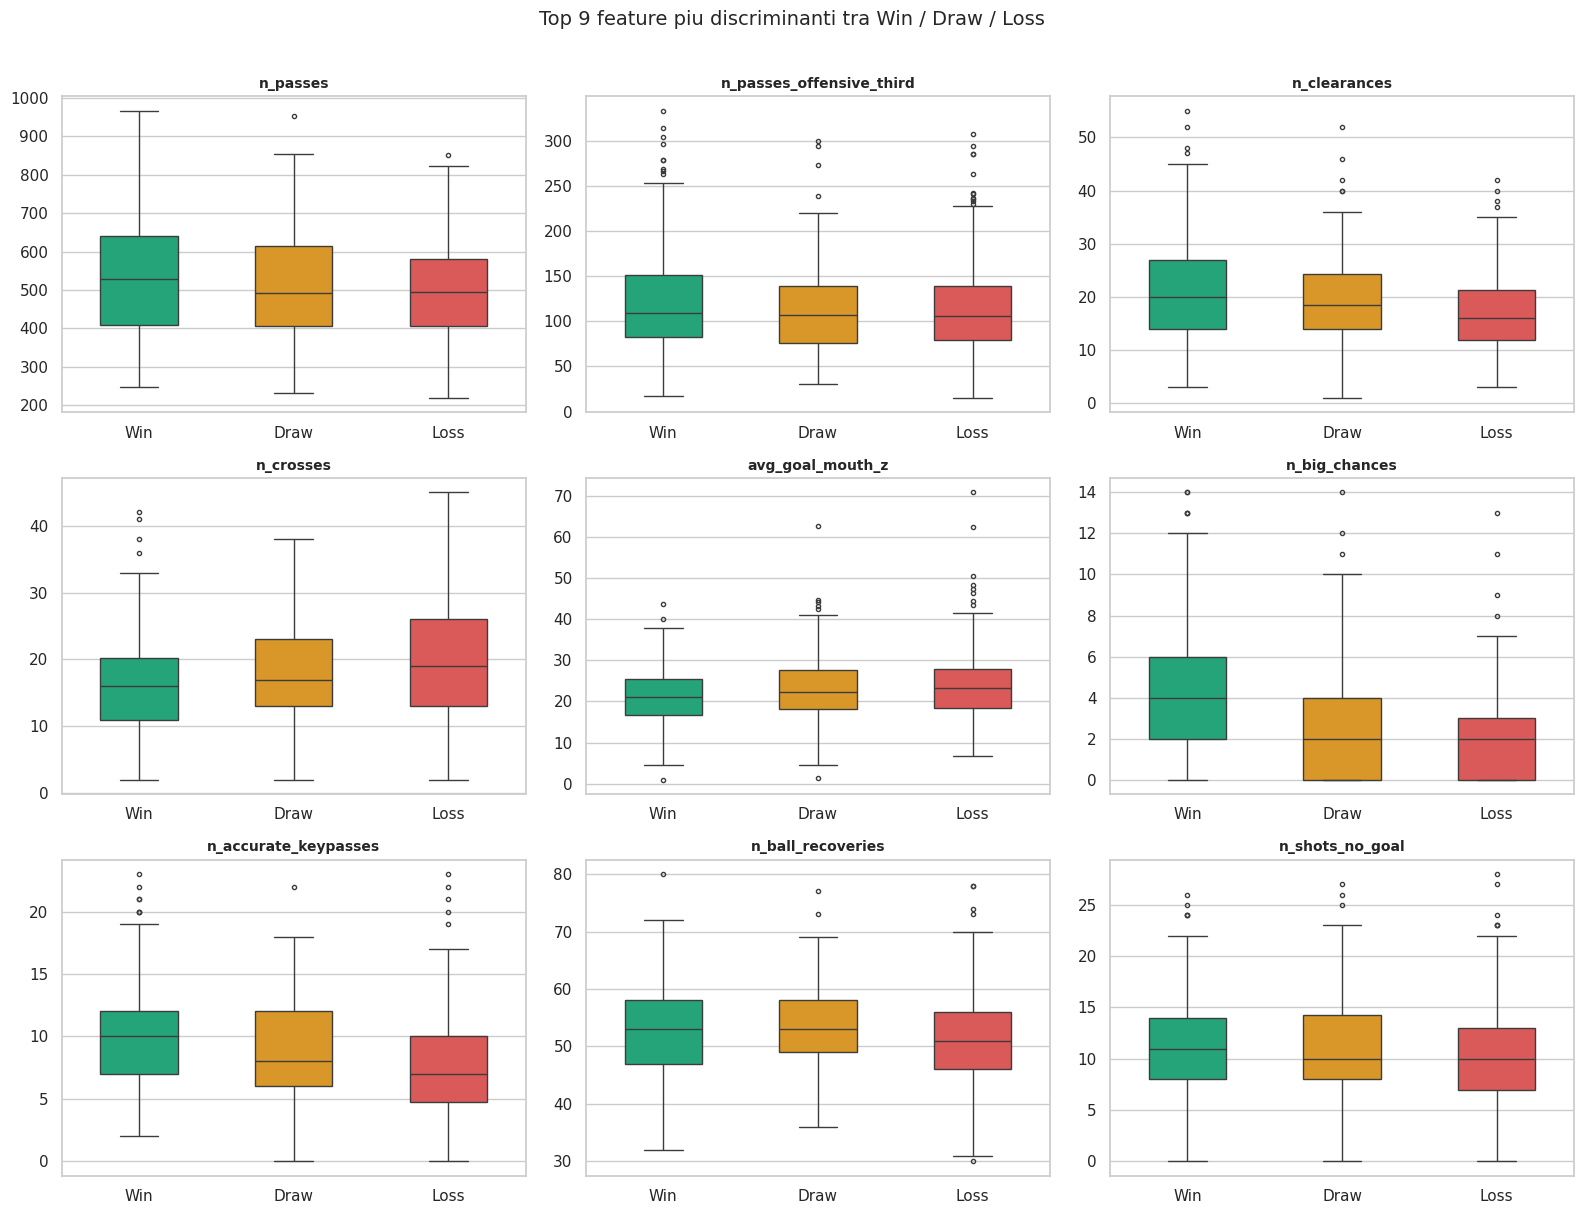

In [7]:
# Boxplot: top 9 feature piu discriminanti
top_features = diff_win_loss.sort_values(ascending=False).head(9).index.tolist()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, feat in zip(axes.flatten(), top_features):
    sns.boxplot(data=features, x="outcome", y=feat,
                order=OUTCOME_ORDER, palette=PALETTE,
                ax=ax, width=0.5, fliersize=3)
    ax.set_title(feat, fontsize=10, fontweight="bold")
    ax.set_xlabel(""); ax.set_ylabel("")

plt.suptitle("Top 9 feature piu discriminanti tra Win / Draw / Loss",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

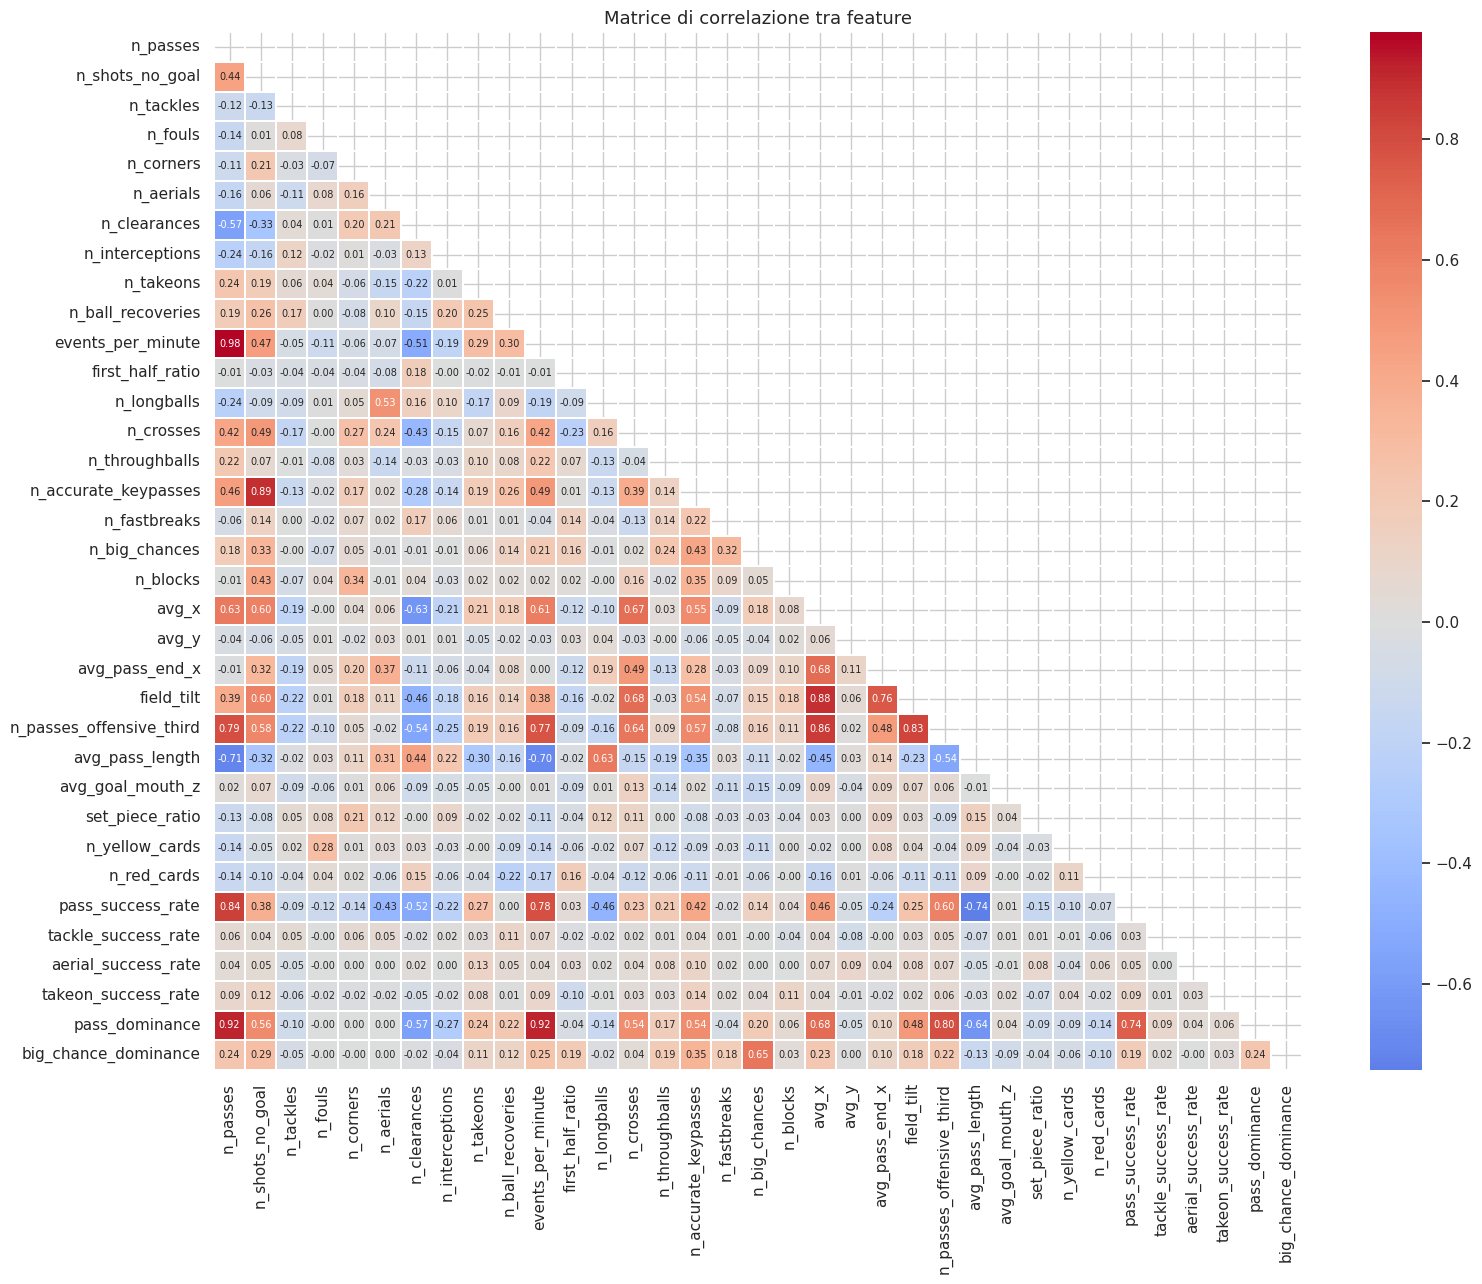

In [8]:
# Matrice di correlazione tra feature
fig, ax = plt.subplots(figsize=(16, 13))
corr = features[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.3, annot_kws={"size": 7})
ax.set_title("Matrice di correlazione tra feature", fontsize=13)
plt.tight_layout()
plt.show()

## Salvataggio `features.parquet`

Il dataset aggregato viene salvato in `data/processed/features.parqueto caricherà e definirà al suo interno `FEATURE_COLS_ML`, che esclude esplicitamente `n_goals` e `shot_conversion_rate` per prevenire il data leakage nell'addestramento dei classificatori.

In [9]:
# Salvataggio Gold Layer
Path('data/processed').mkdir(parents=True, exist_ok=True)
features.to_parquet('data/processed/features.parquet', engine='pyarrow', compression='snappy')

print(f'Dataset Gold salvato correttamente.')
print(f'  Percorso: data/processed/features.parquet')
print(f'  Dimensioni: {features.shape[0]:,} righe x {features.shape[1]} colonne')
print(f'  Colonne: {list(features.columns)}')

Dataset Gold salvato correttamente.
  Percorso: data/processed/features.parquet
  Dimensioni: 760 righe x 40 colonne
  Colonne: ['match_id', 'teamId', 'n_passes', 'n_shots_no_goal', 'n_tackles', 'n_fouls', 'n_corners', 'n_aerials', 'n_clearances', 'n_interceptions', 'n_takeons', 'n_ball_recoveries', 'events_per_minute', 'first_half_ratio', 'n_longballs', 'n_crosses', 'n_throughballs', 'n_accurate_keypasses', 'n_fastbreaks', 'n_big_chances', 'n_blocks', 'avg_x', 'avg_y', 'avg_pass_end_x', 'field_tilt', 'n_passes_offensive_third', 'avg_pass_length', 'avg_goal_mouth_z', 'set_piece_ratio', 'n_yellow_cards', 'n_red_cards', 'pass_success_rate', 'tackle_success_rate', 'aerial_success_rate', 'takeon_success_rate', 'goals_scored', 'goals_conceded', 'outcome', 'pass_dominance', 'big_chance_dominance']
